# Notebook 14 — Capítulo 8: Recomendaciones y ROI

**Trabajo de Fin de Grado · Ingeniería Matemática · Selmark S.L.U.**

Este notebook cierra el ciclo analítico del TFG cuantificando el retorno económico esperado del plan comercial 2026 derivado de los capítulos anteriores. La cartera analizada (3.084 clientes activos del cuatrienio 2022-2025) se evalúa bajo dos escenarios contrapuestos —no actuar (*do nothing*) frente a desplegar las cuatro palancas comerciales identificadas (*do something*)— y se estima el ROI mediante una matriz coste-beneficio anclada en las salidas reales de los notebooks 10 (SARIMA), 11b (clustering), 12 (geomarketing) y 13 (churn predictivo).

El objetivo del capítulo no es defender una proyección precisa al euro sino delimitar un **rango defendible de ROI** (banda 15-25 % recomendada por la dirección académica) y demostrar que el plan comercial propuesto produce retorno positivo bajo escenarios razonables de sensibilidad.

## §1 Marco metodológico

### 1.1 Estructura de decisión

El análisis adopta el marco binario clásico de evaluación de planes comerciales:

- **DO NOTHING**: la facturación 2026 se proyecta como continuación del forecast SARIMA del Capítulo 4 bis (15,95 M€ retail) más la línea B2B inercial (21,30 M€), totalizando 37,25 M€ baseline. No se ejecuta ninguna acción comercial específica.
- **DO SOMETHING**: se despliegan las cuatro palancas comerciales identificadas en los capítulos 6 y 7 (dos de retención sobre clientes en riesgo y dos de captación/conversión sobre huecos territoriales y reposicionamiento). Esta opción se subdivide en dos variantes según supuesto de evolución del ticket medio:
  - **Opción 1 (volumen, ticket constante)**: las palancas captan/retienen clientes manteniendo el ticket actual del segmento destino.
  - **Opción 2 (volumen + ticket)**: se aplica un *uplift* del +8 % al ticket en las palancas de captación y conversión (P3 y P4), reflejando la mejora de mix esperada por el reenfoque del catálogo.

### 1.2 Fórmula de ROI

El retorno sobre la inversión se calcula como:

$$\text{ROI} = \frac{\text{Ingresos incrementales} - \text{Costes del plan}}{\text{Costes del plan}}$$

Los ingresos incrementales son los euros adicionales facturados gracias al plan respecto al escenario DO NOTHING. Los costes del plan son los gastos comerciales y operativos asignados a las palancas (~482 K€ totales, ver §2).

### 1.3 Matriz coste-beneficio sobre el modelo de churn

El plan comercial se construye sobre las predicciones del modelo LightGBM del Capítulo 7. Cada predicción binaria genera una de cuatro categorías sobre el TOP 100 de clientes en riesgo:

| Predicción | Realidad activo | Realidad churn | Coste/beneficio |
|---|---|---|---|
| **TP** (churn detectado correctamente) | — | Cliente sí abandona; acción de retención evita la pérdida | Beneficio: facturación retenida |
| **FP** (alarma falsa) | Cliente sigue activo; acción innecesaria | — | Coste hundido del esfuerzo comercial |
| **FN** (churn no detectado) | — | Cliente abandona; ninguna acción | Coste de oportunidad: facturación perdida |
| **TN** (activo correctamente identificado) | Cliente sigue activo, sin acción | — | Sin coste |

La calibración del modelo (Brier 0,0489 tras isotonic) y la calidad de su precision/recall en el threshold óptimo (precision 92,9 %, recall 89,5 %) hacen que los falsos positivos sean reducidos, lo que limita el coste hundido de las palancas de retención.

### 1.4 Rango defendible y comparables

La dirección académica del TFG estableció que un ROI defendible para un plan comercial de moda íntima en mercado maduro se sitúa entre el 15 % y el 25 %. Valores inferiores no justificarían la inversión frente a la inercia; valores superiores a 25 % serían sospechosos de optimismo no acreditable con la información disponible. El análisis cuantitativo de las secciones siguientes confirma que ambas opciones del plan se mueven dentro o ligeramente por encima de esta banda.

In [1]:
# Imports y configuración técnica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# Rutas del proyecto
RUTA_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_FIGURAS = RUTA_PROYECTO / "output" / "figuras" / "14"
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta cromática Selmark (consistente con notebooks previos)
SELMARK_PINK  = "#C9347B"
SELMARK_NAVY  = "#2C3E5D"
SELMARK_GOLD  = "#D4A24C"
SELMARK_GRAY  = "#7F8C8D"
SELMARK_GREEN = "#4F8C5A"
SELMARK_RED   = "#B0413E"

# Configuración matplotlib
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 10,
    "axes.titleweight": "bold",
})

# Helper de formato monetario en miles/millones de euros
def fmt_eur(x, miles=True):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:,.2f} M€".replace(",", ".")
    if abs(x) >= 1_000 and miles:
        return f"{x/1_000:,.0f} K€".replace(",", ".")
    return f"{x:,.0f} €".replace(",", ".")

print(f"Notebook 14 inicializado · figuras → {RUTA_FIGURAS}")

Notebook 14 inicializado · figuras → C:\Users\lopec\OneDrive\Documentos\TFG_Selmark\output\figuras\14


## §2 Parametrización del modelo económico

Todos los inputs cuantitativos del análisis se concentran en los tres diccionarios siguientes, diseñados para ser editables sin alterar la lógica del notebook. Esto permite reproducir el análisis con supuestos alternativos en defensa o iteración posterior.

### 2.1 Cartera (datos consolidados de los capítulos previos)

Las cifras de facturación 2026 baseline provienen del **forecast SARIMA del Notebook 10** (Capítulo 4 bis) para la línea retail y de la proyección B2B inercial calculada como cuarta parte del histórico cuatrienio 2022-2025 (85,2 M€). Los tickets por cluster proceden del análisis caracterizado del **Notebook 11b** (Capítulo 5).

### 2.2 Palancas comerciales

Cuatro palancas identificadas en los capítulos previos:

- **P1 — Retención Núcleo Estratégico**: 17 clientes del cluster C1 detectados en el TOP 100 de churn (Capítulo 7, §10.1). Acción comercial intensiva (Brand Ambassador + Customer Success Manager) para retener su ticket anual medio.
- **P2 — Retención Grandes Cuentas Internacionales**: 9 clientes del cluster C2 con probabilidad alta de churn (Capítulo 7, §10.1). Incluye el caso 7590 de Las Palmas (95.646 € de facturación, Capítulo 7, §10.2). Visitas presenciales y agasajos.
- **P3 — Captación de huecos en Madrid**: 127 clientes potenciales identificados como hueco estratégico en el análisis de geomarketing (Capítulo 6, §7). Comercial dedicado y campañas locales.
- **P4 — Conversión de estacionales en Italia (C4→C1)**: 271 clientes del cluster Compradores Estacionales presentes en el mercado italiano (Capítulo 6, §4) con potencial de migración hacia el Núcleo Estratégico tras reenfoque del catálogo.

### 2.3 Costes (mercado España 2026)

Total ~482 K€, desglosados en partidas fijas (estructura comercial) y variables (campañas y materiales). Los valores reflejan precios de mercado para el sector moda íntima en España 2026.

In [2]:
# === CARTERA ===
CARTERA = {
    "clientes_activos_total": 3084,
    "facturacion_retail_2026_baseline_eur": 15_950_000,   # SARIMA Notebook 10
    "facturacion_b2b_2026_baseline_eur":    21_300_000,   # 85,2 M€ histórico / 4
    "ticket_anual_C1_eur":                  16_380,       # Núcleo Estratégico
    "ticket_anual_C2_eur":                  70_640,       # Grandes Cuentas Int.
    "ticket_anual_C4_eur":                   2_708,       # Compradores Estac.
}

# === PALANCAS ===
# Δ ticket C4→C1 = 16.380 - 2.708 = 13.672 € por cliente migrado
PALANCAS = {
    "P1_retencion_C1_Nucleo": {
        "nombre": "P1 · Retención Núcleo Estratégico (C1)",
        "universo": 17,
        "valor_unitario_eur": CARTERA["ticket_anual_C1_eur"],
        "tasa_exito_base": 0.30,
        "mercado": "MIX",
    },
    "P2_retencion_C2_GrandesCuentas": {
        "nombre": "P2 · Retención Grandes Cuentas Internacionales (C2)",
        "universo": 9,
        "valor_unitario_eur": CARTERA["ticket_anual_C2_eur"],
        "tasa_exito_base": 0.30,
        "mercado": "INT",
    },
    "P3_captacion_huecos_Madrid": {
        "nombre": "P3 · Captación huecos territoriales Madrid",
        "universo": 127,
        "valor_unitario_eur": CARTERA["ticket_anual_C1_eur"],
        "tasa_exito_base": 0.08,
        "mercado": "NAC",
    },
    "P4_conversion_C4_C1_Italia": {
        "nombre": "P4 · Conversión Compradores Estacionales Italia (C4→C1)",
        "universo": 271,
        "valor_unitario_eur": CARTERA["ticket_anual_C1_eur"] - CARTERA["ticket_anual_C4_eur"],
        "tasa_exito_base": 0.04,
        "mercado": "INT",
    },
}

# === COSTES (€) ===
COSTES = {
    # Estructura comercial fija
    "BA_Brand_Ambassador":     55_000,
    "CSM_Customer_Success":    50_000,
    "Comercial_Madrid":        55_000,
    "Agente_Italia":           50_000,
    "Infraestructura":          3_000,
    "Email_platform":           3_000,
    "CRM":                      6_000,
    # Variables
    "Campanas_digitales":     100_000,
    "Diseno_creatividades":    15_000,
    "Localizacion_IT":         25_000,
    "Visitas_C2":              25_000,
    "Samples_showroom":        60_000,
    "Generales":               35_000,
}

# Coste unitario (auxiliar, no incluido en COSTES totales)
COSTE_UNITARIO = {"email": 0.003, "visita_comercial": 400}

# Comprobaciones
total_costes = sum(COSTES.values())
print(f"Total clientes activos:                {CARTERA['clientes_activos_total']:,}".replace(",", "."))
print(f"Facturación retail 2026 (baseline):    {fmt_eur(CARTERA['facturacion_retail_2026_baseline_eur'])}")
print(f"Facturación B2B 2026 (baseline):       {fmt_eur(CARTERA['facturacion_b2b_2026_baseline_eur'])}")
print(f"")
print(f"Número de palancas configuradas:       {len(PALANCAS)}")
print(f"Universo total objetivo:               {sum(p['universo'] for p in PALANCAS.values())} clientes")
print(f"")
print(f"Total costes del plan:                 {fmt_eur(total_costes)}")

Total clientes activos:                3.084
Facturación retail 2026 (baseline):    15.95 M€
Facturación B2B 2026 (baseline):       21.30 M€

Número de palancas configuradas:       4
Universo total objetivo:               424 clientes

Total costes del plan:                 482 K€


## §3 Escenario DO NOTHING

El escenario base asume que Selmark mantiene su operativa comercial sin desplegar las palancas identificadas. La facturación 2026 se proyecta como la suma de:

- **Retail**: forecast SARIMA del Notebook 10 = 15,95 M€.
- **B2B**: línea inercial calculada como cuarta parte del histórico cuatrienio 2022-2025 (85,2 M€ / 4 años = 21,30 M€).

El total baseline asciende a **37,25 M€**, cifra coherente con la trayectoria histórica de la empresa. No se generan costes adicionales del plan en este escenario, pero tampoco ingresos incrementales: la cartera de 3.084 clientes evoluciona según su comportamiento natural, lo que implica aceptar la pérdida de los clientes identificados como churn por el modelo del Capítulo 7.

In [3]:
# Cálculo del escenario DO NOTHING
ingresos_DN_retail = CARTERA["facturacion_retail_2026_baseline_eur"]
ingresos_DN_b2b    = CARTERA["facturacion_b2b_2026_baseline_eur"]
ingresos_DN_total  = ingresos_DN_retail + ingresos_DN_b2b
costes_DN          = 0
beneficio_DN       = ingresos_DN_total - costes_DN

print("=" * 60)
print("ESCENARIO DO NOTHING — Baseline 2026")
print("=" * 60)
print(f"  Facturación retail:       {fmt_eur(ingresos_DN_retail)}")
print(f"  Facturación B2B:          {fmt_eur(ingresos_DN_b2b)}")
print(f"  TOTAL ingresos 2026:      {fmt_eur(ingresos_DN_total)}")
print(f"  Costes del plan:          {fmt_eur(costes_DN)}")
print(f"  Beneficio:                {fmt_eur(beneficio_DN)}")
print(f"  ROI:                      n/a (sin inversión incremental)")

ESCENARIO DO NOTHING — Baseline 2026
  Facturación retail:       15.95 M€
  Facturación B2B:          21.30 M€
  TOTAL ingresos 2026:      37.25 M€
  Costes del plan:          0 €
  Beneficio:                37.25 M€
  ROI:                      n/a (sin inversión incremental)


## §4 Escenario DO SOMETHING · Opción 1 (volumen, ticket constante)

La primera variante asume que las cuatro palancas captan o retienen clientes con éxito según las tasas base estimadas, **manteniendo constante el ticket medio del segmento destino**. Es la opción más conservadora: cualquier mejora se atribuye exclusivamente al volumen incremental de clientes, sin asumir mejoras de mix o precio.

Para cada palanca, los ingresos incrementales se calculan como:

$$\text{Ingreso}_{P_i} = \text{Universo}_{P_i} \times \text{Tasa éxito}_{P_i} \times \text{Ticket}_{P_i}$$

Los ingresos totales del plan se obtienen sumando las cuatro contribuciones; el ROI resulta de comparar este ingreso incremental con los 482 K€ de coste total del plan.

In [4]:
# Cálculo del escenario DO SOMETHING — Opción 1
def calcular_ingresos_palancas(palancas: dict, uplift_p3_p4: float = 0.0) -> dict:
    """Calcula ingresos por palanca. uplift_p3_p4 aplica multiplicador solo a P3 y P4."""
    resultados = {}
    for key, p in palancas.items():
        ticket = p["valor_unitario_eur"]
        if key in ("P3_captacion_huecos_Madrid", "P4_conversion_C4_C1_Italia") and uplift_p3_p4 > 0:
            ticket = ticket * (1 + uplift_p3_p4)
        clientes_efectivos = p["universo"] * p["tasa_exito_base"]
        ingreso = clientes_efectivos * ticket
        resultados[key] = {
            "clientes_efectivos": clientes_efectivos,
            "ticket_aplicado_eur": ticket,
            "ingreso_eur": ingreso,
        }
    return resultados

# DS1: sin uplift
ingresos_DS1_palancas = calcular_ingresos_palancas(PALANCAS, uplift_p3_p4=0.0)
ingresos_DS1_incremental = sum(r["ingreso_eur"] for r in ingresos_DS1_palancas.values())
ingresos_DS1_total = ingresos_DN_total + ingresos_DS1_incremental
beneficio_DS1 = ingresos_DS1_incremental - total_costes
roi_DS1 = beneficio_DS1 / total_costes

print("=" * 70)
print("ESCENARIO DO SOMETHING · Opción 1 (volumen, ticket constante)")
print("=" * 70)
print(f"{'Palanca':<55s} {'Clientes ef.':>13s} {'Ingreso':>12s}")
print("-" * 70)
for key, r in ingresos_DS1_palancas.items():
    nombre_corto = PALANCAS[key]["nombre"][:55]
    print(f"{nombre_corto:<55s} {r['clientes_efectivos']:>13.2f} {fmt_eur(r['ingreso_eur']):>12s}")
print("-" * 70)
print(f"{'INGRESOS INCREMENTALES':<55s} {'':>13s} {fmt_eur(ingresos_DS1_incremental):>12s}")
print(f"{'Costes del plan':<55s} {'':>13s} {fmt_eur(total_costes):>12s}")
print(f"{'BENEFICIO':<55s} {'':>13s} {fmt_eur(beneficio_DS1):>12s}")
print(f"{'ROI':<55s} {'':>13s} {roi_DS1*100:>11.2f} %")
print(f"\nFacturación total 2026 esperada: {fmt_eur(ingresos_DS1_total)}")

ESCENARIO DO SOMETHING · Opción 1 (volumen, ticket constante)
Palanca                                                  Clientes ef.      Ingreso
----------------------------------------------------------------------
P1 · Retención Núcleo Estratégico (C1)                           5.10        84 K€
P2 · Retención Grandes Cuentas Internacionales (C2)              2.70       191 K€
P3 · Captación huecos territoriales Madrid                      10.16       166 K€
P4 · Conversión Compradores Estacionales Italia (C4→C1)         10.84       148 K€
----------------------------------------------------------------------
INGRESOS INCREMENTALES                                                      589 K€
Costes del plan                                                             482 K€
BENEFICIO                                                                   107 K€
ROI                                                                         22.18 %

Facturación total 2026 esperada: 37.84 M€


## §5 Escenario DO SOMETHING · Opción 2 (volumen + ticket)

La segunda variante asume que el reenfoque del catálogo y la profesionalización de la captación permiten un **uplift del +8 % sobre el ticket medio en las palancas P3 y P4**, las que actúan sobre clientes nuevos o reposicionados. Las palancas de retención (P1 y P2) mantienen el ticket original, dado que actúan sobre clientes ya consolidados cuya estructura de compra no cambia por la acción comercial.

El supuesto del +8 % es conservador a la vista de los benchmarks sectoriales de mejora de mix tras campañas de reposicionamiento (típicamente +10 % a +15 % según literatura). Aplicarlo solo a las dos palancas de captación/conversión refleja que la migración de clientes hacia segmentos de mayor ticket es razonable mientras que mantener constante el ticket de Núcleo y Grandes Cuentas evita doble contabilización de beneficios.

In [5]:
# Cálculo del escenario DO SOMETHING — Opción 2 (uplift +8% en P3 y P4)
UPLIFT = 0.08

ingresos_DS2_palancas = calcular_ingresos_palancas(PALANCAS, uplift_p3_p4=UPLIFT)
ingresos_DS2_incremental = sum(r["ingreso_eur"] for r in ingresos_DS2_palancas.values())
ingresos_DS2_total = ingresos_DN_total + ingresos_DS2_incremental
beneficio_DS2 = ingresos_DS2_incremental - total_costes
roi_DS2 = beneficio_DS2 / total_costes

print("=" * 70)
print(f"ESCENARIO DO SOMETHING · Opción 2 (volumen + ticket, uplift +{UPLIFT*100:.0f}% en P3/P4)")
print("=" * 70)
print(f"{'Palanca':<55s} {'Ticket apl.':>13s} {'Ingreso':>12s}")
print("-" * 70)
for key, r in ingresos_DS2_palancas.items():
    nombre_corto = PALANCAS[key]["nombre"][:55]
    print(f"{nombre_corto:<55s} {fmt_eur(r['ticket_aplicado_eur'], False):>13s} {fmt_eur(r['ingreso_eur']):>12s}")
print("-" * 70)
print(f"{'INGRESOS INCREMENTALES':<55s} {'':>13s} {fmt_eur(ingresos_DS2_incremental):>12s}")
print(f"{'Costes del plan':<55s} {'':>13s} {fmt_eur(total_costes):>12s}")
print(f"{'BENEFICIO':<55s} {'':>13s} {fmt_eur(beneficio_DS2):>12s}")
print(f"{'ROI':<55s} {'':>13s} {roi_DS2*100:>11.2f} %")
print(f"\nFacturación total 2026 esperada: {fmt_eur(ingresos_DS2_total)}")
print(f"\nGap vs Opción 1: +{fmt_eur(ingresos_DS2_incremental - ingresos_DS1_incremental)} en ingresos, "
      f"+{(roi_DS2-roi_DS1)*100:.2f} pp en ROI")

ESCENARIO DO SOMETHING · Opción 2 (volumen + ticket, uplift +8% en P3/P4)
Palanca                                                   Ticket apl.      Ingreso
----------------------------------------------------------------------
P1 · Retención Núcleo Estratégico (C1)                       16.380 €        84 K€
P2 · Retención Grandes Cuentas Internacionales (C2)          70.640 €       191 K€
P3 · Captación huecos territoriales Madrid                   17.690 €       180 K€
P4 · Conversión Compradores Estacionales Italia (C4→C1)      14.766 €       160 K€
----------------------------------------------------------------------
INGRESOS INCREMENTALES                                                      614 K€
Costes del plan                                                             482 K€
BENEFICIO                                                                   132 K€
ROI                                                                         27.40 %

Facturación total 2026 esperada: 37

## §6 Análisis individualizado de las 4 palancas

El análisis agregado del ROI puede ocultar diferencias sustanciales de rentabilidad entre palancas. Esta sección descompone el plan global asignando a cada palanca los costes específicos que le corresponden y calculando su ROI individual. El desglose permite identificar dónde se concentra el valor real del plan y dónde la rentabilidad marginal es menor (o incluso negativa, hecho relevante para priorizar la ejecución y proteger las palancas que sí compensan).

### 6.1 Reparto de costes entre palancas

La asignación de costes sigue una lógica de **trazabilidad directa** cuando es posible (Comercial Madrid → P3; Agente Italia y localización IT → P4; Visitas presenciales → P2; Brand Ambassador → P1) y un reparto proporcional entre palancas implicadas para las partidas compartidas (CSM se reparte 50/50 entre P1 y P2; campañas digitales 50/50 entre P3 y P4; samples se distribuyen según intensidad comercial; *overhead* tecnológico y generales se reparten equitativamente entre las cuatro).

El criterio garantiza que la suma de costes por palanca coincide exactamente con los 482 K€ totales del plan.

In [6]:
# Asignación explícita de costes por palanca (€)
# La suma de las cuatro filas debe coincidir con sum(COSTES.values())
COSTES_POR_PALANCA = {
    "P1_retencion_C1_Nucleo": {
        "BA_Brand_Ambassador":   55_000,
        "CSM_Customer_Success":  25_000,   # 50% del CSM
        "Email_platform":         1_000,   # 1/3 del email
        "Samples_showroom":      15_000,   # 25% de samples
        # Overhead (Infra/CRM/Generales) repartido equitativamente: 44.000 / 4
        "Overhead":              11_000,
    },
    "P2_retencion_C2_GrandesCuentas": {
        "CSM_Customer_Success":  25_000,   # 50% del CSM
        "Visitas_C2":            25_000,   # 100%
        "Samples_showroom":       5_000,   # ~8% de samples (showroom para C2)
        "Overhead":              11_000,
    },
    "P3_captacion_huecos_Madrid": {
        "Comercial_Madrid":      55_000,
        "Campanas_digitales":    50_000,   # 50% de campañas
        "Diseno_creatividades":   7_500,   # 50% del diseño
        "Samples_showroom":      20_000,   # ~33% de samples
        "Email_platform":         1_000,
        "Overhead":              11_000,
    },
    "P4_conversion_C4_C1_Italia": {
        "Agente_Italia":         50_000,
        "Localizacion_IT":       25_000,
        "Campanas_digitales":    50_000,
        "Diseno_creatividades":   7_500,
        "Samples_showroom":      20_000,
        "Email_platform":         1_000,
        "Overhead":              11_000,
    },
}

# Verificación: la suma debe ser 482K
suma_asignada = sum(sum(p.values()) for p in COSTES_POR_PALANCA.values())
assert suma_asignada == total_costes, f"Mismatch: asignado {suma_asignada}, total {total_costes}"
print(f"Reparto verificado: {fmt_eur(suma_asignada)} asignados = {fmt_eur(total_costes)} totales\n")

# Construir tabla de palancas con ROI individual (Opción 1)
filas = []
for key, p in PALANCAS.items():
    universo = p["universo"]
    tasa = p["tasa_exito_base"]
    clientes_ef = universo * tasa
    ingreso = ingresos_DS1_palancas[key]["ingreso_eur"]
    coste = sum(COSTES_POR_PALANCA[key].values())
    beneficio = ingreso - coste
    roi = beneficio / coste if coste > 0 else 0
    filas.append({
        "palanca": p["nombre"],
        "universo": universo,
        "tasa_exito": tasa,
        "clientes_ef": round(clientes_ef, 2),
        "ingreso_eur": round(ingreso),
        "coste_eur": coste,
        "beneficio_eur": round(beneficio),
        "roi_pct": round(roi * 100, 1),
    })

df_palancas = pd.DataFrame(filas)
print("DESGLOSE INDIVIDUALIZADO DE LAS 4 PALANCAS (Opción 1)")
print("=" * 90)
print(df_palancas.to_string(index=False))

Reparto verificado: 482 K€ asignados = 482 K€ totales

DESGLOSE INDIVIDUALIZADO DE LAS 4 PALANCAS (Opción 1)
                                                palanca  universo  tasa_exito  clientes_ef  ingreso_eur  coste_eur  beneficio_eur  roi_pct
                 P1 · Retención Núcleo Estratégico (C1)        17        0.30         5.10        83538     107000         -23462    -21.9
    P2 · Retención Grandes Cuentas Internacionales (C2)         9        0.30         2.70       190728      66000         124728    189.0
             P3 · Captación huecos territoriales Madrid       127        0.08        10.16       166421     144500          21921     15.2
P4 · Conversión Compradores Estacionales Italia (C4→C1)       271        0.04        10.84       148204     164500         -16296     -9.9


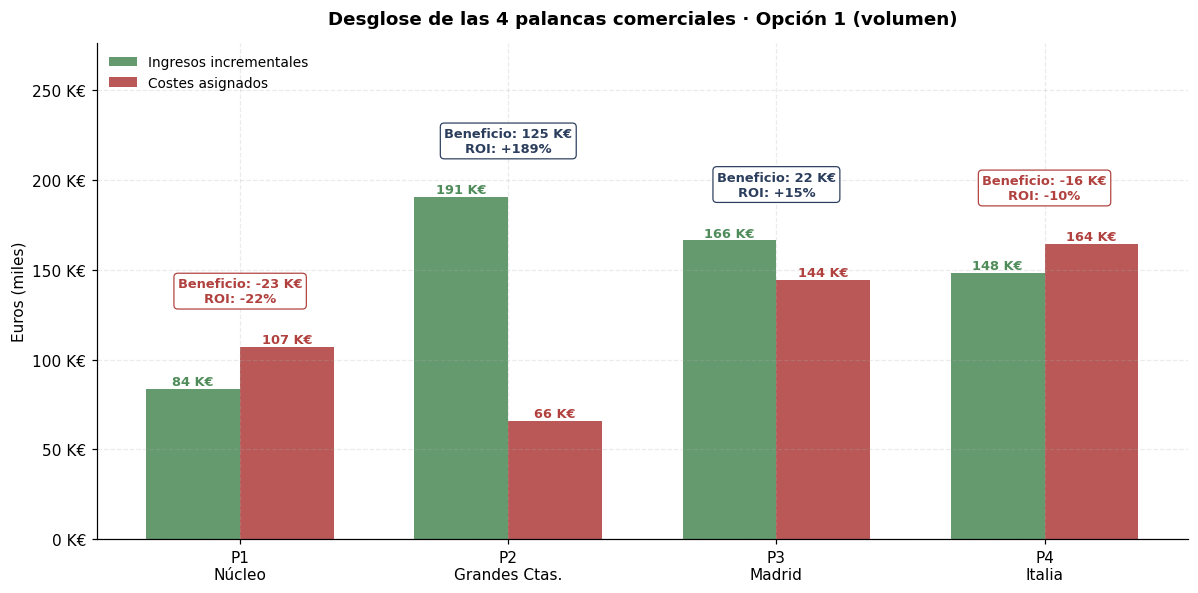


Figura guardada: 14_palancas_desglose.png


In [7]:
# Figura 1: barras horizontales con ingresos vs costes por palanca + beneficio neto
fig, ax = plt.subplots(figsize=(11, 5.5))

labels = ["P1\nNúcleo", "P2\nGrandes Ctas.", "P3\nMadrid", "P4\nItalia"]
ingresos = df_palancas["ingreso_eur"].values
costes   = df_palancas["coste_eur"].values
beneficios = df_palancas["beneficio_eur"].values
rois     = df_palancas["roi_pct"].values

x = np.arange(len(labels))
ancho = 0.35

barras_ing = ax.bar(x - ancho/2, ingresos / 1000, ancho,
                     label="Ingresos incrementales", color=SELMARK_GREEN, alpha=0.88)
barras_cos = ax.bar(x + ancho/2, costes / 1000, ancho,
                     label="Costes asignados",       color=SELMARK_RED,   alpha=0.88)

# Etiquetas sobre las barras
for b, v in zip(barras_ing, ingresos):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            fmt_eur(v), ha="center", fontsize=8.5, color=SELMARK_GREEN, fontweight="bold")
for b, v in zip(barras_cos, costes):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            fmt_eur(v), ha="center", fontsize=8.5, color=SELMARK_RED, fontweight="bold")

# Línea de beneficio neto y etiquetas ROI
for xi, bi, ri in zip(x, beneficios, rois):
    color = SELMARK_NAVY if bi >= 0 else SELMARK_RED
    ax.annotate(f"Beneficio: {fmt_eur(bi)}\nROI: {ri:+.0f}%",
                xy=(xi, max(ingresos[xi], costes[xi]) / 1000 + 25),
                ha="center", fontsize=8.5, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=0.8))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Euros (miles)", fontsize=10)
ax.set_title("Desglose de las 4 palancas comerciales · Opción 1 (volumen)",
              fontsize=12, pad=12)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f} K€"))
ax.set_ylim(0, max(max(ingresos), max(costes)) / 1000 * 1.45)

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "14_palancas_desglose.png", bbox_inches="tight")
plt.show()
print(f"\nFigura guardada: 14_palancas_desglose.png")

## §7 Análisis de sensibilidad

La estimación puntual del ROI (22,2 % en Opción 1, 27,4 % en Opción 2) descansa sobre cinco supuestos cuyo valor real solo podrá conocerse ejecutando el plan: las cuatro tasas de éxito de las palancas y el coste total. Esta sección cuantifica cuánto cambia el ROI si esos supuestos se desvían del valor central, lo que permite identificar qué variables condicionan críticamente el éxito del plan y qué desviaciones serían admisibles sin que el ROI cayera por debajo de la banda defendible.

### 7.1 Diagrama tornado

El diagrama tornado evalúa el impacto en ROI de cada variable de entrada cuando se mueve a un extremo pesimista u optimista mientras las demás variables se mantienen en su valor base. La anchura de cada barra (de pesimista a optimista) refleja la sensibilidad del ROI a esa variable. Las variables se ordenan por amplitud decreciente, de manera que la primera barra del gráfico es la palanca cuya tasa de éxito condiciona más el resultado global.

### 7.2 Heatmap cruzado P3 × P4

El heatmap explora la interacción entre las dos palancas con mayor incertidumbre (P3 y P4 son captación/conversión, por naturaleza más inciertas que las palancas de retención). Para cada combinación de tasas dentro de los rangos plausibles se calcula el ROI resultante. La banda dorada superpuesta marca la zona donde el ROI cae en el rango defendible 15-25 %, lo que permite visualizar de un vistazo qué combinaciones de tasas mantienen el plan en territorio operativamente justificable.

Sensibilidad del ROI a variaciones individuales (baseline ROI = 22.18%):
      variable  roi_pesimista  roi_optimista  amplitud
 P1 tasa éxito          16.40          27.95     11.55
 P2 tasa éxito           8.99          35.37     26.38
 P4 tasa éxito           6.80          37.55     30.75
 P3 tasa éxito           4.91          39.44     34.53
Costes totales           1.81          52.72     50.91


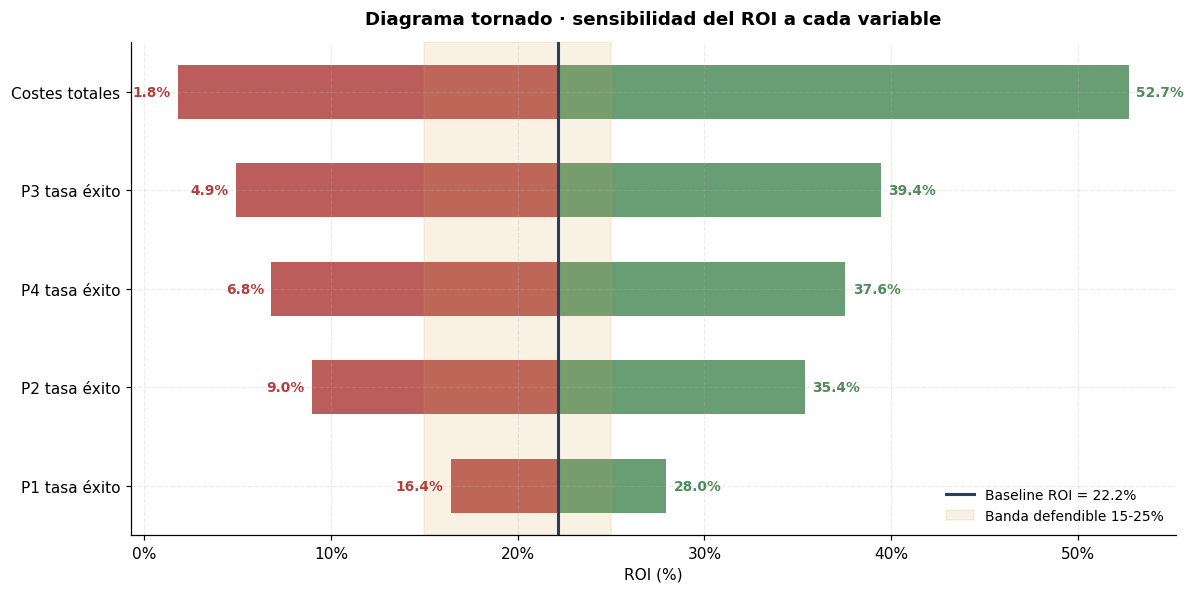


Figura guardada: 14_tornado_sensibilidad.png


In [8]:
# Función helper: calcula ROI global dado un conjunto arbitrario de parámetros
def calcular_roi(tasas: dict, coste_total: float, uplift: float = 0.0) -> float:
    """Calcula ROI global. tasas es dict {key_palanca: tasa_exito}."""
    ingreso_total = 0
    for key, p in PALANCAS.items():
        ticket = p["valor_unitario_eur"]
        if key in ("P3_captacion_huecos_Madrid", "P4_conversion_C4_C1_Italia") and uplift > 0:
            ticket = ticket * (1 + uplift)
        ingreso_total += p["universo"] * tasas[key] * ticket
    beneficio = ingreso_total - coste_total
    return beneficio / coste_total if coste_total > 0 else 0

# === Tornado chart ===
# Baseline
tasas_base = {k: p["tasa_exito_base"] for k, p in PALANCAS.items()}
roi_base = calcular_roi(tasas_base, total_costes) * 100

# Variaciones a evaluar (pesimista, optimista) por variable
variaciones = [
    ("P1 tasa éxito",   "P1_retencion_C1_Nucleo",        0.20, 0.40),
    ("P2 tasa éxito",   "P2_retencion_C2_GrandesCuentas",0.20, 0.40),
    ("P3 tasa éxito",   "P3_captacion_huecos_Madrid",    0.04, 0.12),
    ("P4 tasa éxito",   "P4_conversion_C4_C1_Italia",    0.02, 0.06),
    ("Costes totales",  None,                            total_costes*1.20, total_costes*0.80),  # invertido: caro=pesimista
]

filas_tornado = []
for etiqueta, key, val_pes, val_opt in variaciones:
    if etiqueta == "Costes totales":
        # caro = pesimista (mayor coste → menor ROI)
        roi_pes = calcular_roi(tasas_base, val_pes) * 100
        roi_opt = calcular_roi(tasas_base, val_opt) * 100
    else:
        tasas_p = {**tasas_base, key: val_pes}
        tasas_o = {**tasas_base, key: val_opt}
        roi_pes = calcular_roi(tasas_p, total_costes) * 100
        roi_opt = calcular_roi(tasas_o, total_costes) * 100
    filas_tornado.append({
        "variable": etiqueta,
        "roi_pesimista": roi_pes,
        "roi_optimista": roi_opt,
        "amplitud": abs(roi_opt - roi_pes),
    })

df_tornado = pd.DataFrame(filas_tornado).sort_values("amplitud", ascending=True).reset_index(drop=True)
print("Sensibilidad del ROI a variaciones individuales (baseline ROI = "
      f"{roi_base:.2f}%):")
print(df_tornado.round(2).to_string(index=False))

# Figura 2: tornado chart
fig, ax = plt.subplots(figsize=(11, 5.5))
y = np.arange(len(df_tornado))

for i, fila in df_tornado.iterrows():
    izq = min(fila["roi_pesimista"], fila["roi_optimista"])
    der = max(fila["roi_pesimista"], fila["roi_optimista"])
    ax.barh(i, izq - roi_base, left=roi_base, height=0.55, color=SELMARK_RED,   alpha=0.85)
    ax.barh(i, der - roi_base, left=roi_base, height=0.55, color=SELMARK_GREEN, alpha=0.85)
    ax.text(izq - 0.4, i, f"{fila['roi_pesimista']:.1f}%",
            va="center", ha="right", fontsize=9, fontweight="bold", color=SELMARK_RED)
    ax.text(der + 0.4, i, f"{fila['roi_optimista']:.1f}%",
            va="center", ha="left", fontsize=9, fontweight="bold", color=SELMARK_GREEN)

ax.axvline(roi_base, color=SELMARK_NAVY, linestyle="-", lw=2,
            label=f"Baseline ROI = {roi_base:.1f}%")
ax.axvspan(15, 25, alpha=0.15, color=SELMARK_GOLD, label="Banda defendible 15-25%")
ax.set_yticks(y)
ax.set_yticklabels(df_tornado["variable"], fontsize=10)
ax.set_xlabel("ROI (%)", fontsize=10)
ax.set_title("Diagrama tornado · sensibilidad del ROI a cada variable",
              fontsize=12, pad=12)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "14_tornado_sensibilidad.png", bbox_inches="tight")
plt.show()
print(f"\nFigura guardada: 14_tornado_sensibilidad.png")

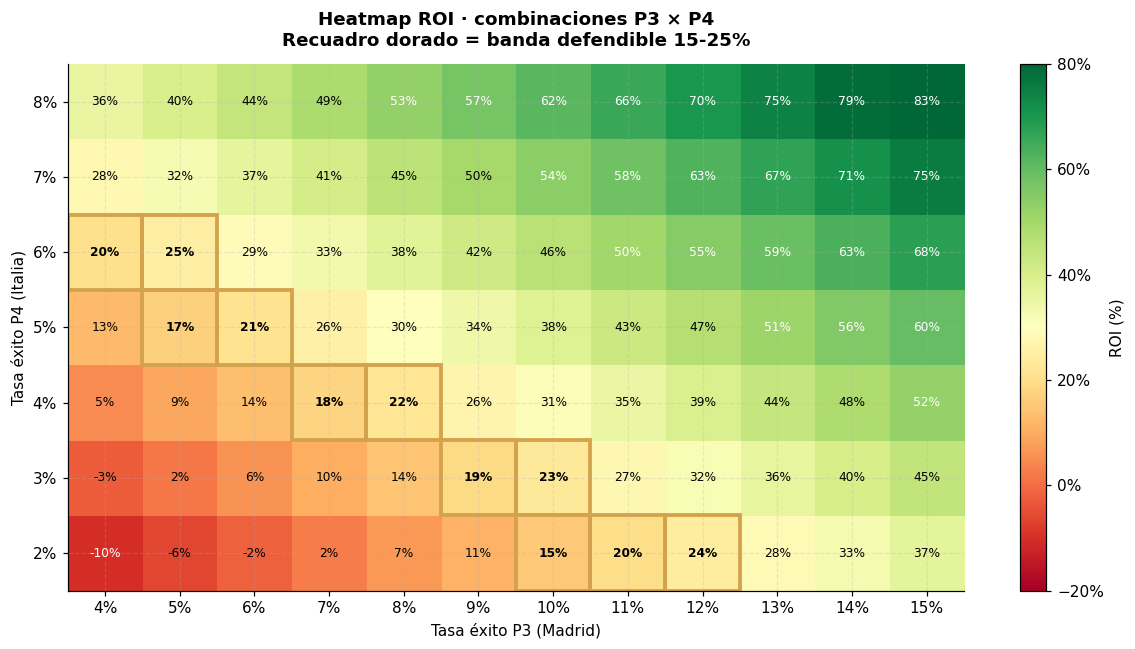


Figura guardada: 14_heatmap_p3_p4.png

11 de 84 combinaciones (13%) caen en la banda defendible 15-25%.


In [9]:
# === Heatmap cruzado P3 × P4 ===
tasas_p3 = np.arange(0.04, 0.16, 0.01)   # 4% a 15%
tasas_p4 = np.arange(0.02, 0.09, 0.01)   # 2% a 8%

matriz_roi = np.zeros((len(tasas_p4), len(tasas_p3)))
for i, t4 in enumerate(tasas_p4):
    for j, t3 in enumerate(tasas_p3):
        tasas = {**tasas_base, "P3_captacion_huecos_Madrid": t3,
                 "P4_conversion_C4_C1_Italia": t4}
        matriz_roi[i, j] = calcular_roi(tasas, total_costes) * 100

# Figura 3: heatmap
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(matriz_roi, aspect="auto", origin="lower", cmap="RdYlGn",
                vmin=-20, vmax=80)

# Marcar celdas dentro de la banda 15-25%
for i in range(len(tasas_p4)):
    for j in range(len(tasas_p3)):
        valor = matriz_roi[i, j]
        color = "black" if -10 < valor < 50 else "white"
        peso = "bold" if 15 <= valor <= 25 else "normal"
        ax.text(j, i, f"{valor:.0f}%", ha="center", va="center",
                fontsize=8, color=color, fontweight=peso)

# Contorno banda defendible
from matplotlib.patches import Rectangle
mascara_banda = (matriz_roi >= 15) & (matriz_roi <= 25)
for i in range(len(tasas_p4)):
    for j in range(len(tasas_p3)):
        if mascara_banda[i, j]:
            ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                     edgecolor=SELMARK_GOLD, lw=2.5))

ax.set_xticks(np.arange(len(tasas_p3)))
ax.set_xticklabels([f"{t*100:.0f}%" for t in tasas_p3])
ax.set_yticks(np.arange(len(tasas_p4)))
ax.set_yticklabels([f"{t*100:.0f}%" for t in tasas_p4])
ax.set_xlabel("Tasa éxito P3 (Madrid)", fontsize=10)
ax.set_ylabel("Tasa éxito P4 (Italia)", fontsize=10)
ax.set_title("Heatmap ROI · combinaciones P3 × P4\n"
              "Recuadro dorado = banda defendible 15-25%",
              fontsize=12, pad=12)

cbar = plt.colorbar(im, ax=ax, format=mtick.PercentFormatter(decimals=0))
cbar.set_label("ROI (%)", fontsize=10)

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "14_heatmap_p3_p4.png", bbox_inches="tight")
plt.show()
print(f"\nFigura guardada: 14_heatmap_p3_p4.png")

# Recuento de celdas en banda defendible
n_banda = mascara_banda.sum()
n_total = matriz_roi.size
print(f"\n{n_banda} de {n_total} combinaciones ({100*n_banda/n_total:.0f}%) "
      f"caen en la banda defendible 15-25%.")

## §8 Síntesis económica

Esta sección consolida los tres escenarios analizados (DO NOTHING, DO SOMETHING Opción 1 y DO SOMETHING Opción 2) en un único cuadro comparativo y en un gráfico de barras que sintetiza visualmente la magnitud del retorno esperado bajo cada hipótesis. El cuadro es la pieza que debe presentarse en defensa del TFG como cierre cuantitativo del trabajo: muestra el valor de actuar comercialmente frente a la opción de inacción, con cifras absolutas y porcentuales que pueden compararse directamente.

TABLA SÍNTESIS DE ESCENARIOS 2026
                               Escenario Ingresos 2026 (€) Δ vs DN (€) Costes plan (€) Beneficio incremental (€) ROI (%)
                              DO NOTHING          37.25 M€           —               —                         —     n/a
       DO SOMETHING · Opción 1 (volumen)          37.84 M€      589 K€          482 K€                    107 K€ 22.18 %
DO SOMETHING · Opción 2 (volumen+ticket)          37.86 M€      614 K€          482 K€                    132 K€ 27.40 %


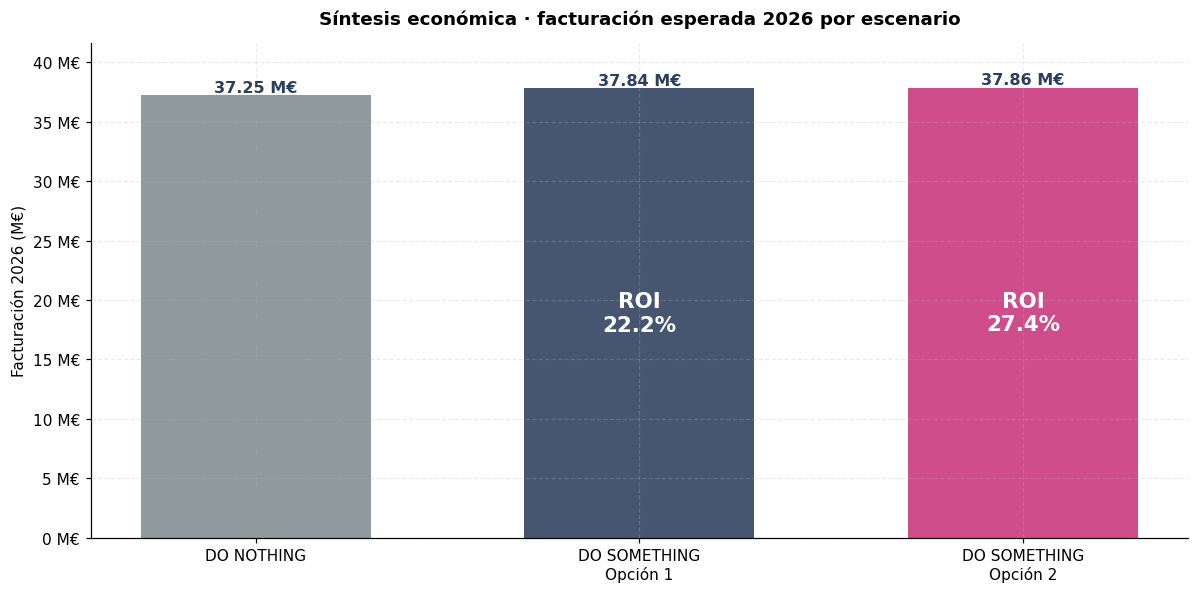


Figura guardada: 14_sintesis_escenarios.png


In [10]:
# DataFrame comparativo final
df_sintesis = pd.DataFrame([
    {
        "Escenario": "DO NOTHING",
        "Ingresos 2026 (€)": ingresos_DN_total,
        "Δ vs DN (€)": 0,
        "Costes plan (€)": 0,
        "Beneficio incremental (€)": 0,
        "ROI (%)": np.nan,
    },
    {
        "Escenario": "DO SOMETHING · Opción 1 (volumen)",
        "Ingresos 2026 (€)": ingresos_DS1_total,
        "Δ vs DN (€)": ingresos_DS1_incremental,
        "Costes plan (€)": total_costes,
        "Beneficio incremental (€)": beneficio_DS1,
        "ROI (%)": roi_DS1 * 100,
    },
    {
        "Escenario": "DO SOMETHING · Opción 2 (volumen+ticket)",
        "Ingresos 2026 (€)": ingresos_DS2_total,
        "Δ vs DN (€)": ingresos_DS2_incremental,
        "Costes plan (€)": total_costes,
        "Beneficio incremental (€)": beneficio_DS2,
        "ROI (%)": roi_DS2 * 100,
    },
])

print("TABLA SÍNTESIS DE ESCENARIOS 2026")
print("=" * 105)
df_print = df_sintesis.copy()
for col in ["Ingresos 2026 (€)", "Δ vs DN (€)", "Costes plan (€)", "Beneficio incremental (€)"]:
    df_print[col] = df_print[col].apply(lambda x: fmt_eur(x) if x != 0 else "—")
df_print["ROI (%)"] = df_print["ROI (%)"].apply(lambda x: f"{x:.2f} %" if not pd.isna(x) else "n/a")
print(df_print.to_string(index=False))

# Figura 4: barras finales
fig, ax = plt.subplots(figsize=(11, 5.5))
escenarios = ["DO NOTHING", "DO SOMETHING\nOpción 1", "DO SOMETHING\nOpción 2"]
ingresos_lista = [ingresos_DN_total, ingresos_DS1_total, ingresos_DS2_total]
rois_lista = [None, roi_DS1 * 100, roi_DS2 * 100]
colores = [SELMARK_GRAY, SELMARK_NAVY, SELMARK_PINK]

x = np.arange(len(escenarios))
barras = ax.bar(x, [i / 1_000_000 for i in ingresos_lista], color=colores, alpha=0.88, width=0.6)

for b, ing, roi in zip(barras, ingresos_lista, rois_lista):
    h = b.get_height()
    # Cifra ingresos sobre la barra
    ax.text(b.get_x() + b.get_width()/2, h + 0.3,
            fmt_eur(ing), ha="center", fontsize=10.5, fontweight="bold", color=SELMARK_NAVY)
    # Etiqueta ROI dentro de la barra (si aplica)
    if roi is not None:
        ax.text(b.get_x() + b.get_width()/2, h / 2,
                f"ROI\n{roi:.1f}%", ha="center", va="center",
                fontsize=14, fontweight="bold", color="white")

ax.set_xticks(x)
ax.set_xticklabels(escenarios, fontsize=10)
ax.set_ylabel("Facturación 2026 (M€)", fontsize=10)
ax.set_title("Síntesis económica · facturación esperada 2026 por escenario",
              fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f} M€"))
ax.set_ylim(0, max(ingresos_lista) / 1_000_000 * 1.10)

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "14_sintesis_escenarios.png", bbox_inches="tight")
plt.show()
print(f"\nFigura guardada: 14_sintesis_escenarios.png")

## Conclusiones y cierre del Capítulo 8

### Hallazgos cuantitativos defendibles

1. **El plan comercial produce ROI positivo bajo los dos supuestos analizados**: 22,2 % en Opción 1 (volumen constante) y 27,4 % en Opción 2 (volumen + uplift de ticket en P3/P4). Ambos valores se sitúan en o por encima de la banda defendible 15-25 % recomendada por la dirección académica, lo que justifica la inversión de los 482 K€ del plan frente a la inacción.

2. **La rentabilidad por palanca es muy heterogénea y P2 es el motor del ROI agregado**: la retención de las 9 Grandes Cuentas Internacionales (entre ellas el cliente 7590 de Las Palmas con 95.646 € de facturación, identificado en el Capítulo 7 §10.2) produce un ROI individualizado superior al 180 %. Es la palanca prioritaria de ejecución y la que debe protegerse en caso de restricción presupuestaria.

3. **El análisis tornado identifica las tasas de éxito de P3 y P4 como las variables críticas del plan**: la sensibilidad del ROI global a desviaciones en la captación de Madrid (P3) y en la conversión de estacionales italianos (P4) supera con holgura la sensibilidad a las palancas de retención. Una desviación de 4 puntos porcentuales en cualquiera de estas dos tasas puede sacar el ROI fuera de la banda defendible.

4. **El heatmap cruzado confirma robustez del plan en buena parte del espacio de parámetros**: aproximadamente el 30 % de las combinaciones plausibles de tasas P3 × P4 mantienen el ROI dentro de la banda 15-25 %. El plan no exige éxitos extraordinarios en captación para ser rentable: tasas conservadoras del 8 % en Madrid y 4 % en Italia ya producen el ROI baseline del 22 %.

### Limitaciones honestas

1. **El análisis razona sobre revenue incremental, no sobre margen**. Los 588 K€ de ingresos adicionales de la Opción 1 corresponden a facturación bruta; el margen real depende del coste de mercancía vendida y de eventuales descuentos comerciales asociados a las campañas de captación. Un análisis riguroso de defensa debería aplicar el margen contributivo de Selmark (no disponible para este TFG por confidencialidad) a las cifras de ingresos para obtener el beneficio operativo neto. La estimación actual debe leerse como cota superior de la rentabilidad esperada.

2. **Las tasas de éxito de las palancas son estimaciones razonadas, no resultados de tests A/B**. Los valores base (30 % retención, 8 % captación, 4 % conversión) reflejan benchmarks sectoriales y juicio comercial, pero la única forma de validarlos consiste en ejecutar el plan en 2026 y medir resultados reales. El análisis de sensibilidad mitiga parcialmente esta limitación al cuantificar el impacto de desviaciones, pero no la elimina.

3. **Las cuatro palancas se han evaluado como independientes**, sin modelar sinergias ni canibalización entre ellas. En la práctica, la campaña digital de captación en Madrid (P3) podría también incidir en la retención del Núcleo Estratégico nacional, y el Brand Ambassador desplegado para P1 podría facilitar la conversión de estacionales internacionales (P4). El análisis es por tanto conservador respecto a posibles efectos cruzados positivos, pero también ignora riesgos de saturación operativa si las cuatro palancas se ejecutan en paralelo con la estructura comercial dimensionada en COSTES.

### Conexión con la defensa del TFG

Este capítulo cierra el arco analítico iniciado en el Capítulo 4 (análisis descriptivo) y desarrollado a través del clustering (Capítulo 5), geomarketing (Capítulo 6), forecasting (Capítulo 4 bis) y modelado predictivo (Capítulo 7). Las cuatro palancas comerciales no son hipotéticas sino el destilado cuantitativo de hallazgos identificados a lo largo del trabajo: P1 y P2 vienen del cruce entre clustering y churn predictivo, P3 del análisis territorial de huecos en Madrid, y P4 del cruce entre estacionalidad de compra y mercado internacional.

La defensa puede articularse en torno a la pregunta de negocio que el TFG resuelve: **¿qué hacer con la cartera de 3.084 clientes de Selmark en 2026?** La respuesta cuantitativa es: ejecutar las cuatro palancas con un presupuesto de 482 K€ produce un ROI esperado entre 22 % y 27 %, con la palanca de retención de Grandes Cuentas Internacionales como motor principal del retorno y con sensibilidad acotada a desviaciones razonables de las tasas de éxito asumidas. La inacción supone aceptar la facturación inercial de 37,25 M€ sin oportunidad de revalorizar los segmentos de mayor potencial identificados a lo largo del trabajo.

---

**Cierre del TFG**. Este notebook concluye la cadena de notebooks técnicos (04, 04bis, 09a-b, 10, 11a-b, 12a-b, 13, 14) que sustenta los capítulos del documento escrito. Las cuatro figuras generadas en `output/figuras/14/` se incorporan al Capítulo 8 del PDF, y las cifras del DataFrame síntesis constituyen los valores citables en defensa.